# Prepare RNA and Motif Data
Following the steps detailed in DynaVelo, prepare the ATAC/z-score data and RNA expression data. These can then be used for model training and evaluation of velocities.

In [1]:
import anndata as ad
import scanpy as sc 
import pandas as pd
import numpy as np
import scvelo as scv

In [2]:
python_data_dir = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data"
r_data_dir = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_preprocessing\data"

# Load RNA total count data
total_counts_path = fr"{python_data_dir}\total_counts.h5ad"
adata_rna = sc.read_h5ad(total_counts_path)

# Load ATAC z-score data
zscore_path = fr"{r_data_dir}\Exp4_ctr_chromvar_data.csv"
data_atac = pd.read_csv(zscore_path, header=0, index_col=0).T
adata_atac = ad.AnnData(data_atac.values, obs=pd.DataFrame(index=data_atac.index), var=pd.DataFrame(index=data_atac.columns))
#adata_atac.write_h5ad(fr"{python_data_dir}\z_scores_raw.h5ad")

In [3]:
# Ensure that both datasets have the same cells
rna_cells = adata_rna.obs_names
atac_cells = adata_atac.obs_names

intersection_cells = rna_cells.intersection(atac_cells)

adata_rna = adata_rna[intersection_cells, :]  # Already in cells-by-gene
adata_atac = adata_atac[intersection_cells, :]  # Convert to cells-by-peak

adata_atac.write_h5ad(fr"{python_data_dir}\z_scores_intersect.h5ad")
adata_rna.write_h5ad(fr"{python_data_dir}\total_counts_intersect.h5ad")

In [16]:
adata_atac.obs

""
Exp4_ctr#AAACAGCCACTAAGTT-1
Exp4_ctr#AAACAGCCAGCATGAG-1
Exp4_ctr#AAACAGCCAGGCCATT-1
Exp4_ctr#AAACAGCCATAATCCG-1
Exp4_ctr#AAACAGCCATTTAAGC-1
...
Exp4_ctr#TTTGTGTTCTGTGCAG-1
Exp4_ctr#TTTGTTGGTAGTTGGC-1
Exp4_ctr#TTTGTTGGTCATCATC-1
Exp4_ctr#TTTGTTGGTTGAGCCG-1


In [25]:
mapping = {
    "LT": "LT-HSC",
    "ST": "ST-HSC",
    "MPP": "MPP",
    "LS_K": "LK"
}

adata_rna.obs["cell_type"] = adata_rna.obs["predicted.id"].map(mapping).fillna("Other")

adata_rna.obs["cell_type"] = pd.Categorical(
    adata_rna.obs["cell_type"],
    categories=["LT-HSC", "ST-HSC", "MPP", "LK", "Other"],
    ordered=False
)

adata_rna.obs["cell_type"].value_counts()

LK        2371
MPP       1997
LT-HSC     637
ST-HSC     375
Other        0
Name: cell_type, dtype: int64

In [26]:
# Add spliced and unspliced layers to the RNA AnnData object
loom_path = r"C:\Users\Nikla\Documents\MoBi_Master_FS.3\Internship AG Höfer\DynaVelo_testing\data\spliced_unspliced_counts.loom"

##### load loom files from velocyto 
ldata = scv.read(loom_path, cache=True)
# ldata.obs_names = [sample_name+'#' + x.split(':')[1][:-1] + '-1' for x in ldata.obs_names]
# ldata.obs['Sample'] = sample_name
ldata.var_names_make_unique()

#ldata = sc.concat(ldata_list, join='inner', label="Sample", keys=sample_to_label.keys(), index_unique=None)

# merge RNA and velocyto data
adata_rna = scv.utils.merge(adata_rna, ldata)

In [27]:
adata_rna.write_h5ad(fr"{python_data_dir}\all_rna_counts.h5ad")

In [28]:
# check spliced and unspliced layer dimensions
print("Spliced layer dimensions:", adata_rna.layers['spliced'].shape)
print("Unspliced layer dimensions:", adata_rna.layers['unspliced'].shape)

Spliced layer dimensions: (5380, 7112)
Unspliced layer dimensions: (5380, 7112)


In [29]:
# Filter RNA data
sc.pp.filter_cells(adata_rna, min_counts=1000)
adata_rna.obs['read_depth_log10'] = np.log10(adata_rna.obs['n_counts'])

#adata_rna = adata_rna[:, ~adata_rna.var_names.isin(['Malat1'])]
scv.pp.filter_genes(adata_rna, min_shared_counts=10)

median_x = np.median(adata_rna.X.toarray().sum(1))
print(f'Median of read depth in X: {median_x}')
sc.pp.normalize_total(adata_rna, target_sum=median_x)

median_s = np.median(adata_rna.layers['spliced'].toarray().sum(1))
print(f'Median of read depth in spliced: {median_s}')
sc.pp.normalize_total(adata_rna, target_sum=median_s, layer='spliced')

median_u = np.median(adata_rna.layers['unspliced'].toarray().sum(1))
print(f'Median of read depth in unspliced: {median_u}')
sc.pp.normalize_total(adata_rna, target_sum=median_u, layer='unspliced')

sc.pp.log1p(adata_rna)
sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000, flavor='seurat', batch_key='Sample')
adata_rna.layers["X_log"] = adata_rna.X.copy()

Filtered out 747 genes that are detected 10 counts (shared).
Median of read depth in X: 1244.130126953125
Median of read depth in spliced: 1417.36767578125
Median of read depth in unspliced: 671.8968505859375


In [30]:
adata_rna.write_h5ad(fr"{python_data_dir}\all_rna_counts_normalized.h5ad")

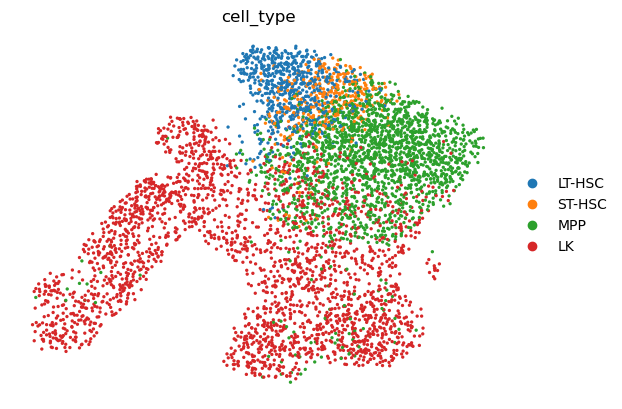

In [31]:
sc.pp.pca(adata_rna, n_comps=30, svd_solver='arpack')
sc.pp.neighbors(adata_rna, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_rna, min_dist=1, spread=1, random_state=0, n_components=2)
sc.pl.umap(adata_rna, show=True, frameon=False, color="cell_type")